In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
path = '../data/uniptm_total_similarity/S_res_db.tab'

In [64]:
data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")

<BarContainer object of 100 artists>

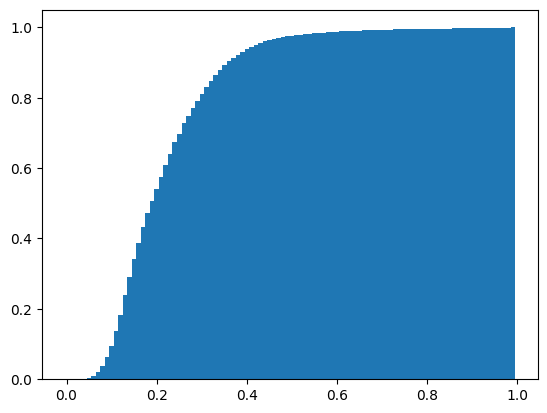

In [74]:
filtered = data[data['query_id'] != data['target_id']]
hist,_  = np.histogram(filtered['similarity'], bins=100) 
hist = hist / np.sum(hist)
hist = np.cumsum(hist)
plt.bar(np.arange(100)/100, hist, width=0.01)

In [76]:
1 - hist[79]

np.float64(0.004633236295050969)

In [36]:
np.average(data[data['query_id'] != data['target_id']]['similarity'])

np.float64(38.697402009291714)

<Axes: >

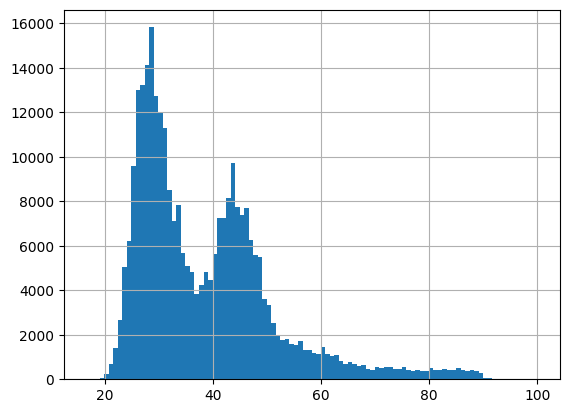

In [ ]:
data[data['query_id'] != data['target_id']]['similarity'].hist(bins=100)

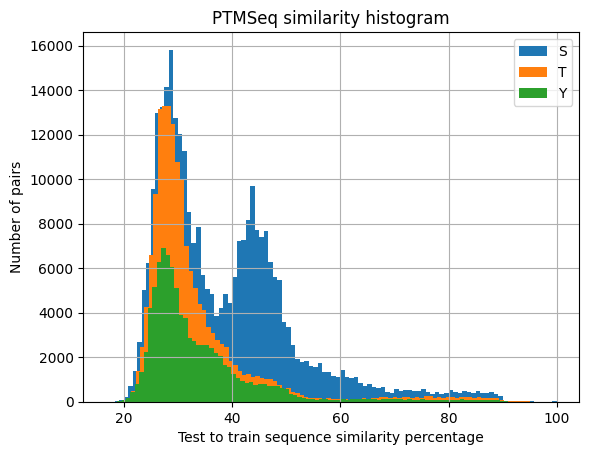

In [ ]:
residues = ['S', 'T', 'Y']

out = {}

for res in residues:
    path = f'../data/uniptm_total_similarity/{res}_res_db.tab'
    data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
    filtered = data[data['query_id'] != data['target_id']]
    out[res] = {}
    out[res]['average_sim'] = np.average(filtered['similarity'])
    out[res]['median_sim'] = np.median(filtered['similarity'])
    out[res]['min_sim'] = np.min(filtered['similarity'])
    out[res]['max_sim'] = np.max(filtered['similarity'])

    filtered['similarity'].hist(bins=10, label=res)
plt.title(f'PTMSeq similarity histogram')
plt.xlabel('Test to train sequence similarity percentage')
plt.ylabel('Number of pairs')
plt.legend()

In [30]:
pd.DataFrame.from_dict(out)

,S,T,Y
average_sim,38.697402,33.220089,33.735266
median_sim,35.200000,29.800000,30.200000
min_sim,16.600000,18.000000,18.700000
max_sim,100.000000,100.000000,100.000000


In [31]:
fold_out = {}
for res in residues:
    fold_out[res] = {}
    for fold in range(5):
        fold_out[res][fold] = current_out = {}
        path = f'../data/uniptm_fold_similarity/uniptm_splits_{res}_fastas/fold{fold}/result_db.tab'
        data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
        filtered = data[data['query_id'] != data['target_id']]
        current_out['average_sim'] = np.average(filtered['similarity'])
        current_out['median_sim'] = np.median(filtered['similarity'])
        current_out['min_sim'] = np.min(filtered['similarity'])
        current_out['max_sim'] = np.max(filtered['similarity'])

In [33]:
for res in residues:
    print(f'Residue {res}')
    df = pd.DataFrame.from_dict(fold_out[res])
    print(df)
    print('--------------------------------------------')

Residue S
                      0          1           2           3          4
average_sim   37.473142  38.142333   38.346614   37.679991  37.513092
median_sim    33.400000  34.400000   34.900000   33.700000  33.800000
min_sim       18.400000  18.200000   18.200000   18.400000  17.200000
max_sim      100.000000  97.900000  100.000000  100.000000  97.700000
--------------------------------------------
Residue T
                     0          1         2          3           4
average_sim  32.217477  32.402433  32.29621  31.924106   32.450871
median_sim   29.300000  29.300000  29.10000  29.000000   29.300000
min_sim      18.200000  18.400000  18.40000  18.200000   18.000000
max_sim      98.800000  97.400000  98.00000  98.000000  100.000000
--------------------------------------------
Residue Y
                    0        1          2          3          4
average_sim  33.65903  33.8964  33.362783  33.682766  33.805875
median_sim   30.00000  30.5000  29.900000  30.100000  30.400000
min

# Phosphosite Section

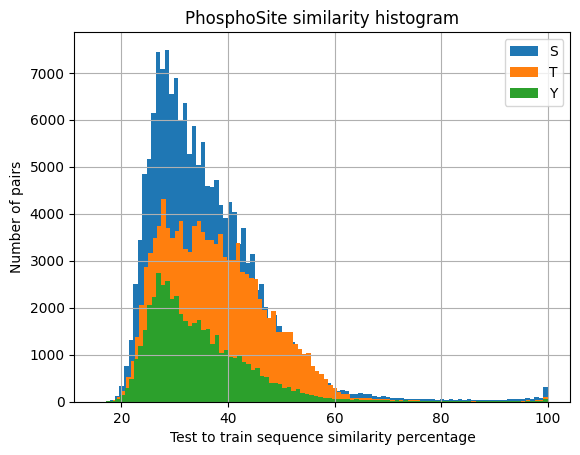

In [52]:
residues = ['S', 'T', 'Y']

out = {}

for res in residues:
    path = f'../data/phosphosite_total_similarity/result_db_{res}.tab'
    data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
    filtered = data[data['query_id'] != data['target_id']]
    # hist,_  = np.histogram(filtered['similarity'], bins=100) 
    # hist = hist / np.sum(hist)
    # hist = np.cumsum(hist)
    # print(1 - hist[79])
    # plt.bar(np.arange(100)/100, hist, width=0.01)
    # plt.show()
    out[res] = {}
    out[res]['average_sim'] = np.average(filtered['similarity'])
    out[res]['median_sim'] = np.median(filtered['similarity'])
    out[res]['min_sim'] = np.min(filtered['similarity'])
    out[res]['max_sim'] = np.max(filtered['similarity'])

    filtered['similarity'].hist(bins=100, label=res)
plt.title(f'PhosphoSite similarity histogram')
plt.xlabel('Test to train sequence similarity percentage')
plt.ylabel('Number of pairs')
plt.legend()

In [54]:
pd.DataFrame.from_dict(out)

,S,T,Y
average_sim,35.926952,37.652701,34.518133
median_sim,33.700000,36.300000,32.200000
min_sim,15.400000,17.600000,15.500000
max_sim,100.000000,100.000000,100.000000


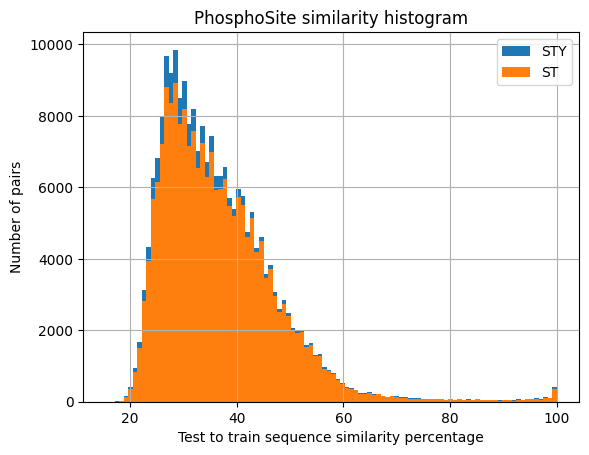

In [56]:
residues = ['STY', 'ST']

out = {}

for res in residues:
    path = f'../data/phosphosite_total_similarity/result_db_{res}.tab'
    data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
    filtered = data[data['query_id'] != data['target_id']]
    out[res] = {}
    out[res]['average_sim'] = np.average(filtered['similarity'])
    out[res]['median_sim'] = np.median(filtered['similarity'])
    out[res]['min_sim'] = np.min(filtered['similarity'])
    out[res]['max_sim'] = np.max(filtered['similarity'])

    filtered['similarity'].hist(bins=100, label=res)
plt.title(f'PhosphoSite similarity histogram')
plt.xlabel('Test to train sequence similarity percentage')
plt.ylabel('Number of pairs')
plt.legend()

In [57]:
pd.DataFrame.from_dict(out)

,STY,ST
average_sim,36.541354,36.716348
median_sim,34.400000,34.700000
min_sim,15.400000,15.400000
max_sim,100.000000,100.000000


In [60]:
residues = ['S', 'T', 'Y', 'ST', 'STY']

fold_out = {}
for res in residues:
    fold_out[res] = {}
    for fold in range(5):
        fold_out[res][fold] = current_out = {}
        path = f'../data/phosphosite_fold_similarity/splits_{res}_fastas/fold{fold}/result_db.tab'
        data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
        filtered = data[data['query_id'] != data['target_id']]
        current_out['average_sim'] = np.average(filtered['similarity'])
        current_out['median_sim'] = np.median(filtered['similarity'])
        current_out['min_sim'] = np.min(filtered['similarity'])
        current_out['max_sim'] = np.max(filtered['similarity'])

In [61]:
for res in residues:
    print(f'Residue {res}')
    df = pd.DataFrame.from_dict(fold_out[res])
    print(df)
    print('--------------------------------------------')

Residue S
                      0           1           2           3           4
average_sim   35.685872   35.846643   36.152945   36.234397   35.630589
median_sim    33.400000   33.800000   33.900000   34.300000   33.300000
min_sim       15.400000   17.900000   17.900000   18.100000   17.600000
max_sim      100.000000  100.000000  100.000000  100.000000  100.000000
--------------------------------------------
Residue T
                      0           1           2          3          4
average_sim   37.300269   37.715355   37.290201   37.94387   37.81415
median_sim    36.000000   36.600000   35.800000   36.50000   36.60000
min_sim       18.400000   17.600000   18.800000   17.90000   18.60000
max_sim      100.000000  100.000000  100.000000  100.00000  100.00000
--------------------------------------------
Residue Y
                    0           1           2           3           4
average_sim   34.5638   34.616405   34.369269   34.306017   34.798958
median_sim    32.2000   32.600

In [77]:
phos_info = pd.read_json('../data/phosphosite_sequences/phosphosite_df.json')

In [79]:
phos_info['sites'].apply(lambda x: len(x)).median()

np.float64(4.0)

In [ ]:
residues = ['S', 'T', 'Y']
for res in residues:
    info = pd.read_json(f'../data/uniptm_info_{res}.json')
    print(f'{res} sites: {info["sites"].apply(lambda x: len(x)).median()}')

S sites: 2.0
T sites: 1.0
Y sites: 1.0


: 

In [20]:
import glob

def plot_similarity_results(residues, title, root_dir):
    out = {}
    for res in residues:
        for path in glob.glob(f'{root_dir}\\*\\splits_{res}_fold*\\similarity.tab'):
            data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
            filtered = data[data['query_id'] != data['target_id']]
            # hist,_  = np.histogram(filtered['similarity'], bins=100) 
            # hist = hist / np.sum(hist)
            # hist = np.cumsum(hist)
            # print(1 - hist[79])
            # plt.bar(np.arange(100)/100, hist, width=0.01)
            # plt.show()
            out[res] = {}
            out[res]['average_sim'] = np.average(filtered['similarity'])
            out[res]['median_sim'] = np.median(filtered['similarity'])
            out[res]['min_sim'] = np.min(filtered['similarity'])
            out[res]['max_sim'] = np.max(filtered['similarity'])

            filtered['similarity'].hist(bins=100, label=f'{res}_fold{path.split("\\")[-2][-1]}', alpha=0.5)
        plt.title(f'{title} similarity histogram')
        plt.xlabel('Test to train sequence similarity percentage')
        plt.ylabel('Number of pairs')
        plt.legend()
        plt.show()

    print(pd.DataFrame.from_dict(out))

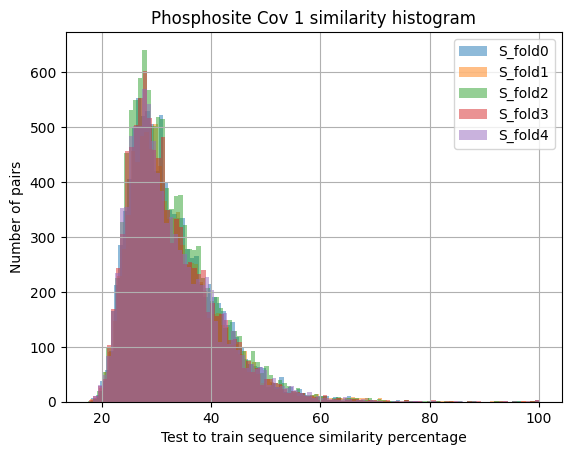

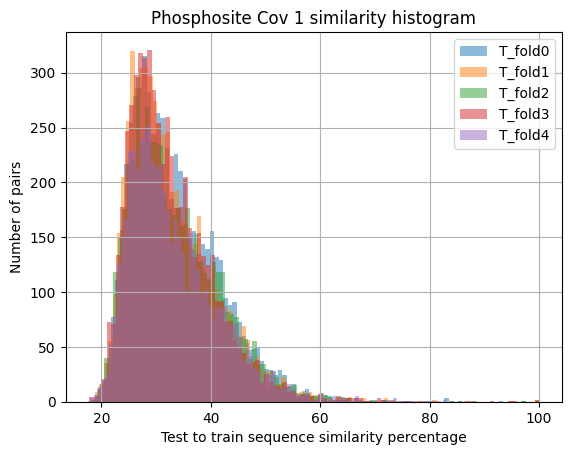

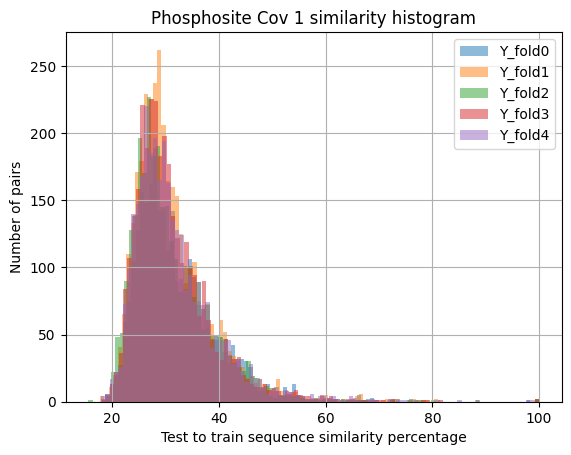

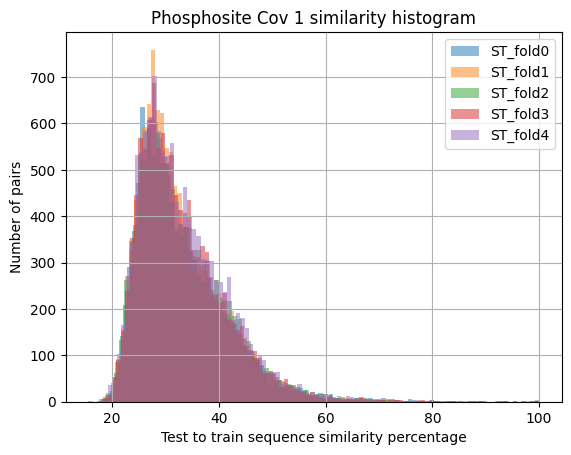

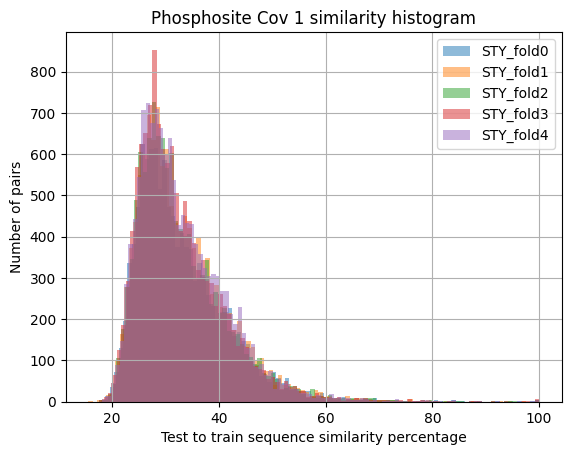

                      S          T          Y          ST         STY
average_sim   32.682714  33.258974  31.700156   33.480516   33.110681
median_sim    30.600000  31.300000  29.800000   31.600000   31.200000
min_sim       18.400000  18.000000  17.900000   17.600000   18.100000
max_sim      100.000000  87.200000  99.300000  100.000000  100.000000


In [21]:
plot_similarity_results(['S', 'T', 'Y', 'ST', 'STY'], 'Phosphosite Cov 1', '../data/dataset_clusters_cov1')

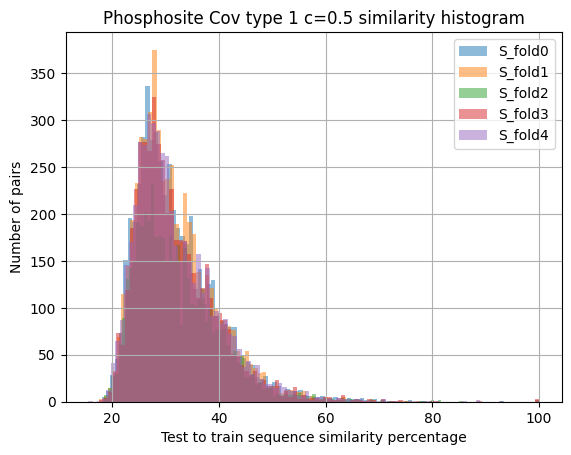

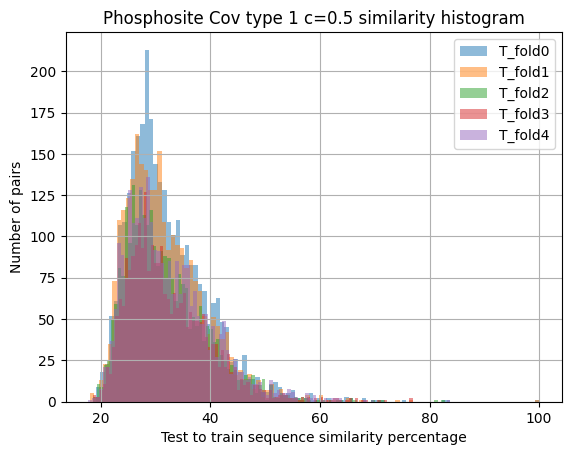

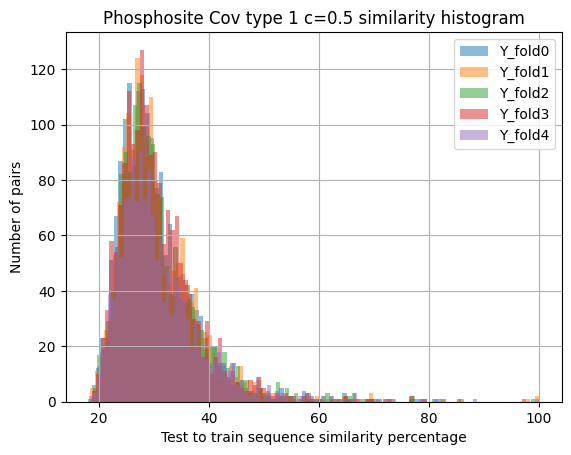

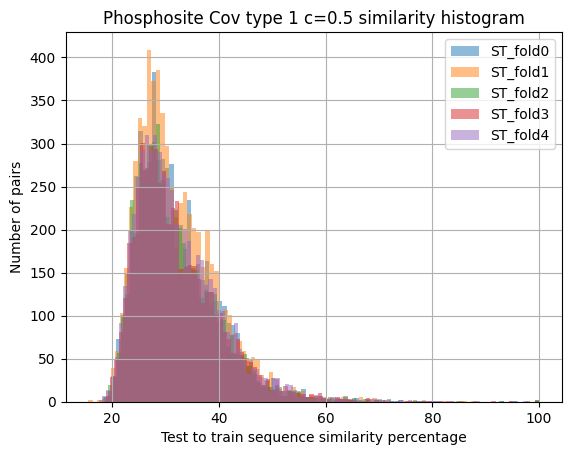

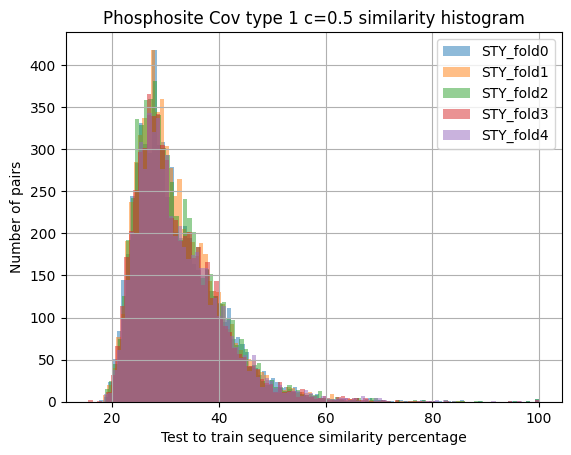

                      S          T          Y         ST         STY
average_sim   32.033433  32.280483  31.003928  32.411002   32.510847
median_sim    30.000000  30.600000  29.100000  30.600000   30.500000
min_sim       15.500000  17.700000  18.200000  18.100000   18.400000
max_sim      100.000000  83.800000  88.700000  97.700000  100.000000


In [22]:
plot_similarity_results(['S', 'T', 'Y', 'ST', 'STY'], 'Phosphosite Cov type 1 c=0.5', '../data/dataset_clusters_cov1_c05')

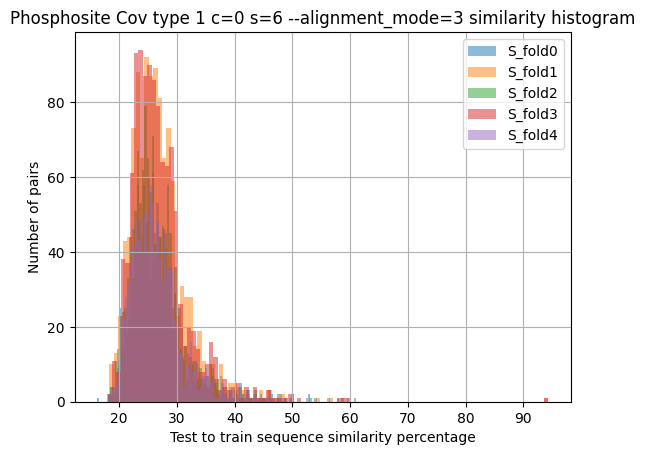

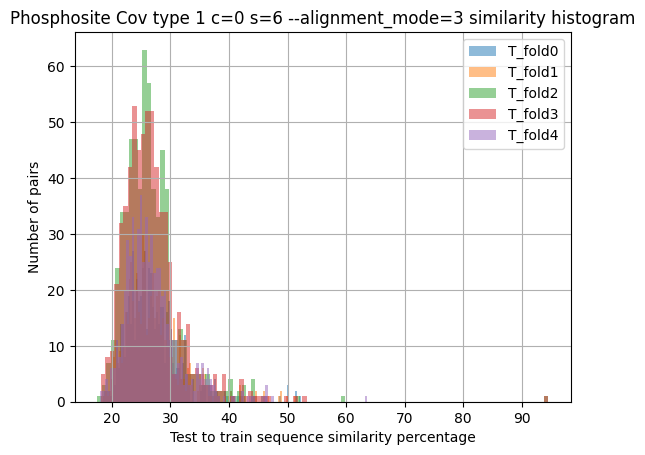

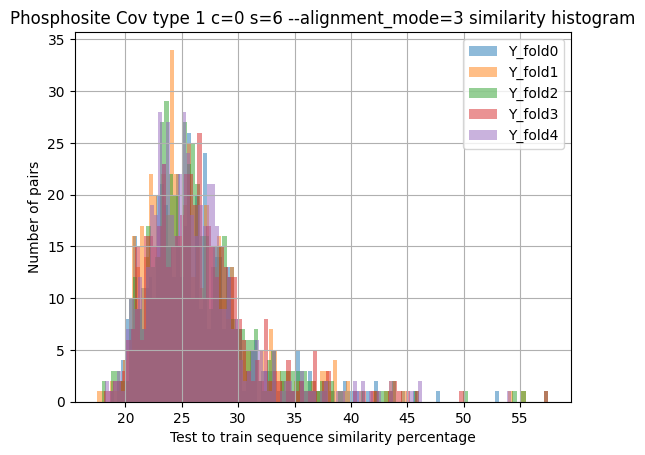

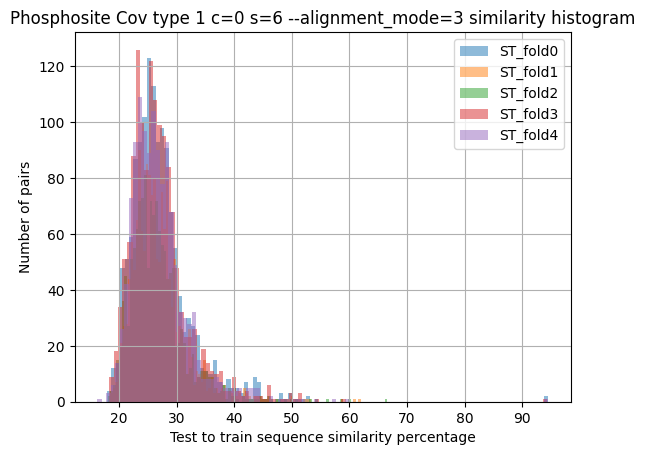

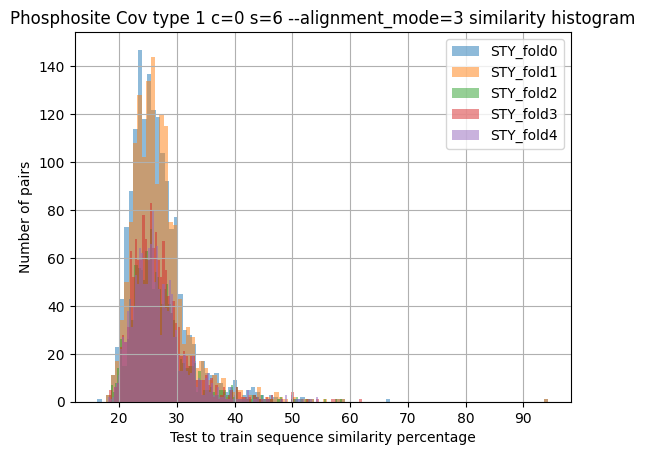

                     S          T          Y         ST      STY
average_sim  26.635135  26.925289  26.142992  27.056791  26.8327
median_sim   25.800000  26.000000  25.300000  26.100000  25.9000
min_sim      18.100000  17.900000  18.200000  16.200000  18.0000
max_sim      59.800000  63.600000  54.200000  94.500000  54.5000


In [23]:
plot_similarity_results(['S', 'T', 'Y', 'ST', 'STY'], 'Phosphosite Cov type 1 c=0 s=6 --alignment_mode=3', '../data/dataset_clusters_cov1_c05_c0_aln_3_s6')

In [49]:
def plot_similarity_results_general(residues, title, root_dir):
    out = {}
    for res in residues:
        for path in glob.glob(f'{root_dir}\\**\\similarity*{res}*.tab', recursive=True):
            data = pd.read_csv(path, names=['query_id', 'target_id', 'similarity', 'alnlen', 'qlen', 'tlen'], sep="\t")
            filtered = data[data['query_id'] != data['target_id']]
            # hist,_  = np.histogram(filtered['similarity'], bins=100) 
            # hist = hist / np.sum(hist)
            # hist = np.cumsum(hist)
            # print(1 - hist[79])
            # plt.bar(np.arange(100)/100, hist, width=0.01)
            # plt.show()
            out[res] = {}
            out[res]['average_sim'] = np.average(filtered['similarity'])
            out[res]['median_sim'] = np.median(filtered['similarity'])
            out[res]['min_sim'] = np.min(filtered['similarity'])
            out[res]['max_sim'] = np.max(filtered['similarity'])

            filtered['similarity'].hist(bins=100, label=f'{res}', alpha=0.5)
        plt.title(f'{title} similarity histogram')
        plt.xlabel('Test to train sequence similarity percentage')
        plt.ylabel('Number of pairs')
        plt.legend()
        plt.show()

    print(pd.DataFrame.from_dict(out))

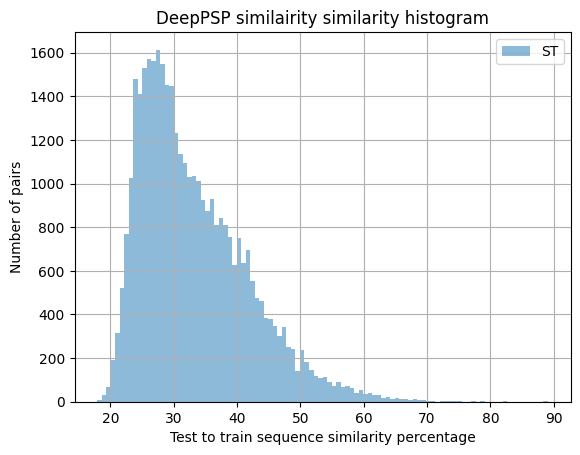

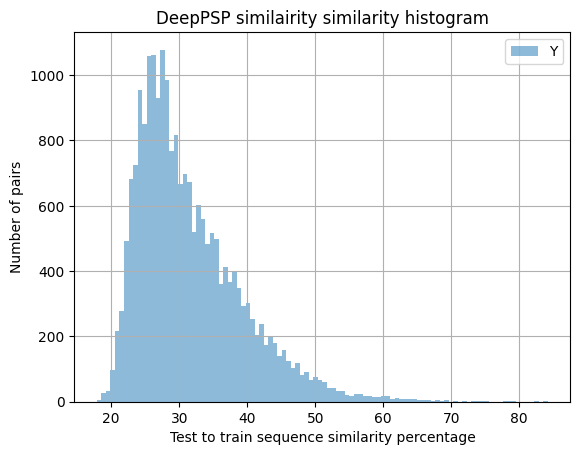

                    ST          Y
average_sim  33.227093  31.547041
median_sim   31.300000  29.600000
min_sim      17.900000  17.900000
max_sim      89.100000  84.200000


In [50]:
plot_similarity_results_general(['ST', 'Y'], 'DeepPSP similairity', '../data/deeppsp')